<a href="https://colab.research.google.com/github/varshinichowdary24/Lovi-app/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print(tf.__version__)

2.20.0


In [ ]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
sns.countplot(y_train)

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7a64802b4fe0> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7a648027a520> (for post_execute):


KeyboardInterrupt: 

In [ ]:
np.isnan(x_train).any()

np.False_

In [ ]:
np.isnan(x_test).any()

np.False_

In [ ]:
input_shape = (28, 28, 1)

x_train=x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
x_train=x_train / 255.0
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)
x_test=x_test/255.0

In [ ]:
y_test.shape

(10000,)

In [ ]:
y_train = tf.one_hot(y_train.astype(np.int32), depth=10)
y_test = tf.one_hot(y_test.astype(np.int32), depth=10)

AttributeError: EagerTensor object has no attribute 'astype'. 
        If you are looking for numpy-related methods, please run the following:
        tf.experimental.numpy.experimental_enable_numpy_behavior()
      

In [ ]:
x_train.shape

(60000, 28, 28, 1)

tf.Tensor([0. 0. 1. 0. 0. 0. 0. 0. 0. 0.], shape=(10,), dtype=float32)


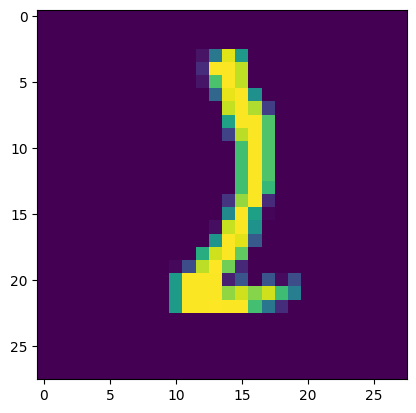

In [ ]:
plt.imshow(x_train[180][:,:,0])
print(y_train[180])

In [ ]:
batch_size = 64
num_classes = 10
epochs = 5

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (5,5), padding='same', activation='relu', input_shape=input_shape),
    tf.keras.layers.Conv2D(32, (5,5), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(strides=(2,2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.RMSprop(epsilon=1e-08), loss='categorical_crossentropy', metrics=['acc'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('acc')>0.995):
      print("\nReached 99.5% accuracy so cancelling training!")
      self.model.stop_training = True

callbacks = myCallback()

In [ ]:
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_split=0.1,
                    callbacks=[callbacks])

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - acc: 0.9317 - loss: 0.2215 - val_acc: 0.9830 - val_loss: 0.0574
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.9777 - loss: 0.0777 - val_acc: 0.9885 - val_loss: 0.0385
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9836 - loss: 0.0580 - val_acc: 0.9905 - val_loss: 0.0351
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9856 - loss: 0.0489 - val_acc: 0.9923 - val_loss: 0.0274
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.9875 - loss: 0.0441 - val_acc: 0.9922 - val_loss: 0.0306


In [ ]:
x_train.shape

(60000, 28, 28, 1)

In [ ]:
y_train.shape

TensorShape([60000, 10])

TypeError: _process_plot_var_args.__call__() got multiple values for argument 'axes'

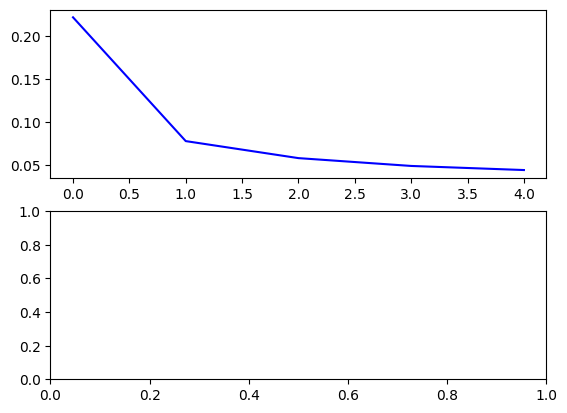

In [ ]:
fig, ax = plt.subplots(2,1)
ax[0].plot(history.history['loss'], color='b', label="Training Loss")
ax[0].plot(history.history['val_loss'], color='r', label="Validation on loss",axes= ax[0])
legend = ax[0].legend(loc='best', shadow=True)

ax[0].plot(history.history['acc'], color='b', label="Training Accuracy")
ax[0].plot(history.history['val_acc'], color='r', label="Validation Accuracy",axes= ax[0])
legend = ax[0].legend(loc='best', shadow=True)